In [3]:
#-----------  imports
import os
from pathlib import Path
import sys

# data
import numpy as np
import pandas as pd
import xarray as xr
import csv
import netCDF4 as nc

# plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import cmocean

# image processing
from skimage import feature, filters
import cv2

# ML
from skfda.ml.clustering import KMeans
from skfda.representation import FDataGrid
from scipy.stats import gaussian_kde
    
import re
import gc
import pywt
import mat73

In [15]:
mission = "2018"
path_in = f"/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration{mission}.nc"
path_out = "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_oceano"
path_temp_sal ="/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2018-01-09-2018-02-01_cropped_mini_bspline.nc"

In [4]:
with xr.open_dataset(path_temp_sal) as ds : 
    print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:                (time: 5, latitude: 20, longitude: 20, depth: 45,
                            bspline_k: 20, knot: 24)
Coordinates:
  * time                   (time) datetime64[ns] 40B 2018-01-10 ... 2018-01-14
  * latitude               (latitude) float32 80B -45.75 -45.67 ... -44.17
  * longitude              (longitude) float32 80B 68.58 68.67 ... 70.08 70.17
  * depth                  (depth) float32 180B 0.494 1.541 ... 3.597e+03
  * bspline_k              (bspline_k) int32 80B 0 1 2 3 4 5 ... 15 16 17 18 19
Dimensions without coordinates: knot
Data variables:
    thetao_reconstructed   (time, latitude, longitude, depth) float32 360kB ...
    thetao_bspline_coeffs  (time, latitude, longitude, bspline_k) float32 160kB ...
    so_reconstructed       (time, latitude, longitude, depth) float32 360kB ...
    so_bspline_coeffs      (time, latitude, longitude, bspline_k) float32 160kB ...
    bspline_knots          (knot) float32 96B ...
Attributes: 

In [6]:
def create_path_figure(folder_comp, title, path_in=path_in, path_out=path_out) : 
    dataset_name = Path(path_in).stem
    save_dir = Path(path_out) / folder_comp
    save_dir.mkdir(parents=True, exist_ok=True)
    path = os.path.join(save_dir, f"{dataset_name}_{title}.png")
    return path

In [22]:
def compare_thetao_original_bspline_reconstructed(
        path_temp=path_temp_sal, path_out=path_out,
        lat_idx=0, lon_idx=0,
        time_indices=None, save=False):

    ds = xr.open_dataset(path_temp)
    depth   = ds["depth"].values
    time    = ds["time"].values
    lat     = ds["latitude"].values[lat_idx]
    lon     = ds["longitude"].values[lon_idx]

    # (time, lat, lon, depth) si transposé, ou (time, depth, lat, lon)
    # on indexe proprement via xarray
    thetao_orig = ds["thetao"].isel(latitude=lat_idx, longitude=lon_idx).values        # (time, depth)
    thetao_rec  = ds["thetao_reconstructed"].isel(latitude=lat_idx, longitude=lon_idx).values
    ds.close()

    if time_indices is None:
        n_time       = thetao_orig.shape[0]
        time_indices = np.linspace(0, n_time - 1, min(4, n_time), dtype=int).tolist()

    n_cols = len(time_indices)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 8), sharey=True)
    if n_cols == 1:
        axes = [axes]

    fig.suptitle(
        f"Reconstruction B-spline thetao — lat={lat:.2f}° lon={lon:.2f}°",
        fontsize=12, fontweight="bold"
    )

    for col, t_idx in enumerate(time_indices):
        ax = axes[col]
        ax.plot(thetao_orig[t_idx], depth, color="black", linewidth=1.4,
                label="original", zorder=5)
        ax.plot(thetao_rec[t_idx],  depth, color="red",   linewidth=0.9,
                alpha=0.85, label="B-spline")
        ax.set_title(
            f"{np.datetime_as_string(time[t_idx], unit='D')}",
            fontsize=9
        )
        ax.set_xlabel("θ (°C)", fontsize=9)
        
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
    axes[0].set_ylabel("Profondeur (m)", fontsize=9)
    plt.tight_layout()

    if save:
        path = create_path_figure(
            "reconstruction_bspline",
            f"thetao_bspline_lat{lat:.2f}_lon{lon:.2f}",
            path_in=path_temp
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

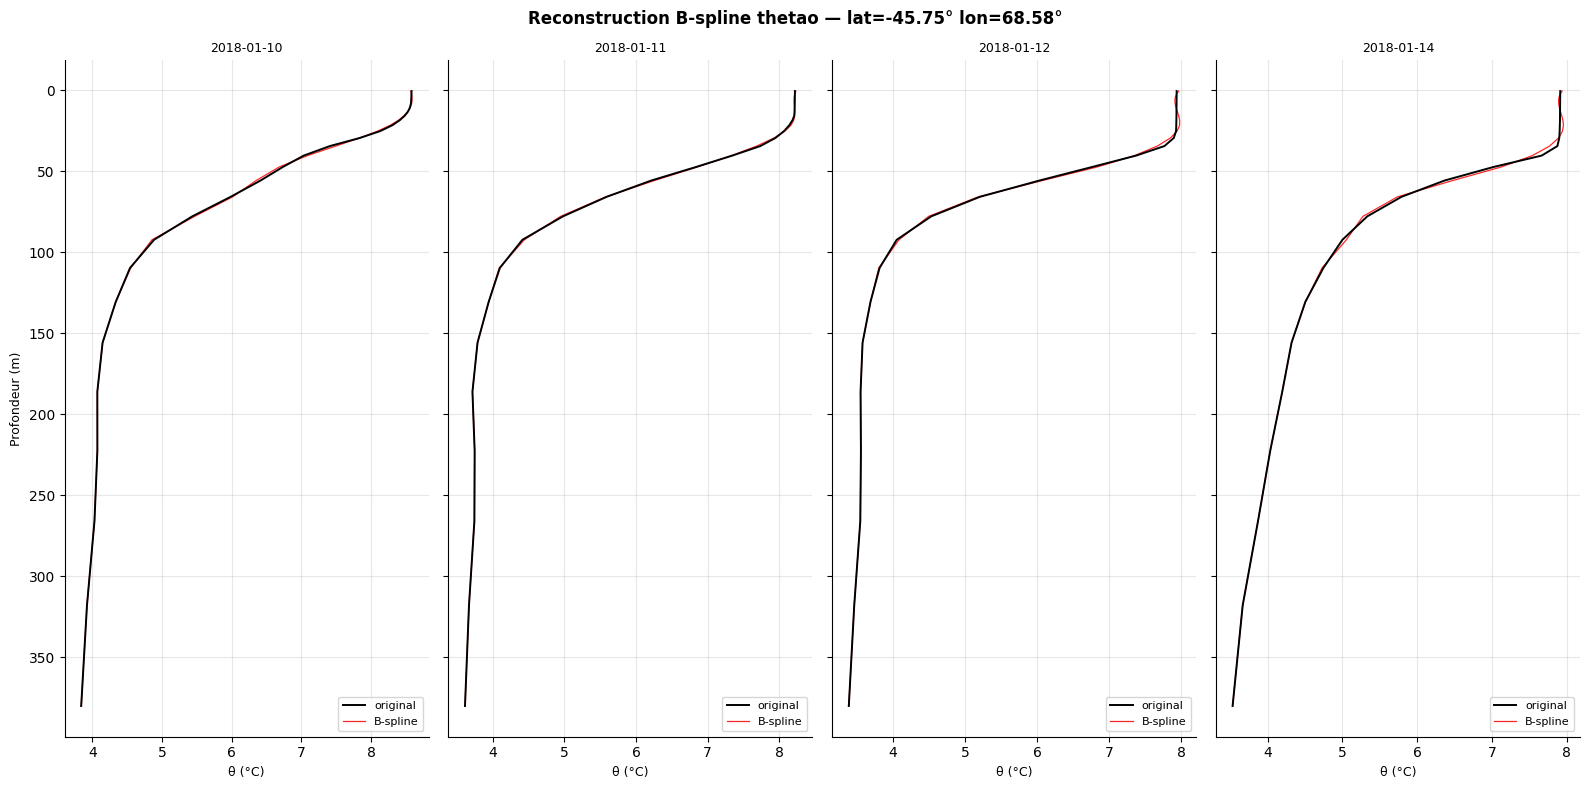

In [23]:
compare_thetao_original_bspline_reconstructed()

In [44]:
def plot_transect_data_env(freq, period, env_var, path_env, target_depth, path_in=path_in, path_out=path_out, save=False):

    input_name = os.path.splitext(os.path.basename(path_env))[0]
    print(input_name)
    periods = {1:"Night", 2:"Sunrise", 3:"Day", 4:"Sunset"}

    # ---------------- ENV DATA ----------------
    ds_env = xr.open_dataset(path_env)

    data = ds_env[env_var].sel(depth=target_depth, method="nearest")
    depth_actual = float(ds_env["depth"].sel(depth=target_depth, method="nearest"))

    lons = ds_env["longitude"].values
    lats = ds_env["latitude"].values
    times = ds_env["time"].values

    map_dates = pd.to_datetime(times).normalize()

    vmin, vmax = float(data.min()), float(data.max())
    depth_label = f"{depth_actual:.0f} m"

    ds_env.close()

    # ---------------- SV DATA ----------------
    ds_sv = xr.open_dataset(path_in)

    mask_period = np.where(ds_sv["day"].values == period)[0]

    ping_lon = ds_sv["longitude"].values[mask_period]
    ping_lat = ds_sv["latitude"].values[mask_period]

    freq_idx = np.where(ds_sv["instrument_frequency"].values == freq)[0][0]

    ping_dates = pd.to_datetime(ds_sv["time"].values[mask_period], unit="s").normalize()

    sv = ds_sv["Sv"]

    ping_sv = (
        sv.isel(channel=freq_idx)
          .isel(time=mask_period)
          .sel(depth=target_depth, method="nearest")
          .values
    )

    depth_sv_actual = float(ds_sv["depth"].sel(depth=target_depth, method="nearest"))

    ds_sv.close()

    print(f"Profondeur température : {depth_actual:.1f} m")
    print(f"Profondeur Sv          : {depth_sv_actual:.1f} m")

    sv_vmin, sv_vmax = np.nanpercentile(ping_sv, [2, 98])
    sv_norm = mcolors.Normalize(vmin=sv_vmin, vmax=sv_vmax)
    sv_cmap = cm.plasma

    # ---------------- LOOP : 1 FIGURE PER DAY ----------------
    for i in range(len(times)):

        fig, ax = plt.subplots(
            figsize=(6, 6),
            subplot_kw={"projection": ccrs.PlateCarree()}
        )

        # ---------------- map setup ----------------
        ax.set_extent(
            [lons.min(), lons.max(), lats.min(), lats.max()],
            crs=ccrs.PlateCarree()
        )

        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        # ---------------- ENV FIELD ----------------
        frame = data.isel(time=i).values

        mesh = ax.pcolormesh(
            lons, lats, frame,
            cmap="RdYlBu_r",
            vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading="auto"
        )

        # =========================
        # SV POINTS
        # =========================
        jour = map_dates[i]
        mask = ping_dates == jour

        if mask.any():
            ax.scatter(
                ping_lon[mask],
                ping_lat[mask],
                c=ping_sv[mask],
                cmap=sv_cmap,
                norm=sv_norm,
                s=8,
                transform=ccrs.PlateCarree(),
                zorder=3
            )

        ax.set_title(f"{jour.date()} — {env_var} & Sv @ {depth_label} - {freq}Hz")
        cax1 = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        cbar1 = fig.colorbar(mesh, cax=cax1)
        cbar1.set_label(f"{env_var} ({depth_label})")

        sm = cm.ScalarMappable(cmap=sv_cmap, norm=sv_norm)
        sm.set_array([])
        cax2 = fig.add_axes([1.04, 0.15, 0.02, 0.7])
        cbar2 = fig.colorbar(sm, cax=cax2)
        cbar2.set_label(f"Sv (dB) — {freq} — {depth_label}")
        # save 
        if save : 
            path = create_path_figure(f"DATA_ENV/map_transect_period/{freq}/{periods[period]}", f"{input_name}_{env_var}_{jour.date()}_{freq}_{periods[period]}_{depth_label}")
            print(path)
            plt.savefig(path, bbox_inches="tight")
            plt.close()
        else : 
            plt.show()


cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2018-01-09-2018-02-01_mini_cropped
Profondeur température : 47.4 m
Profondeur Sv          : 51.0 m


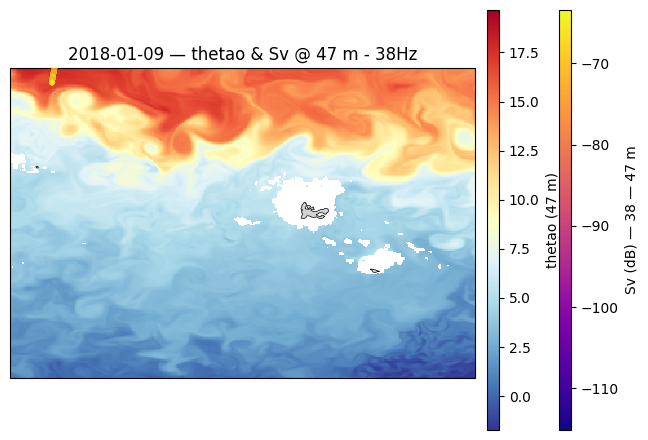

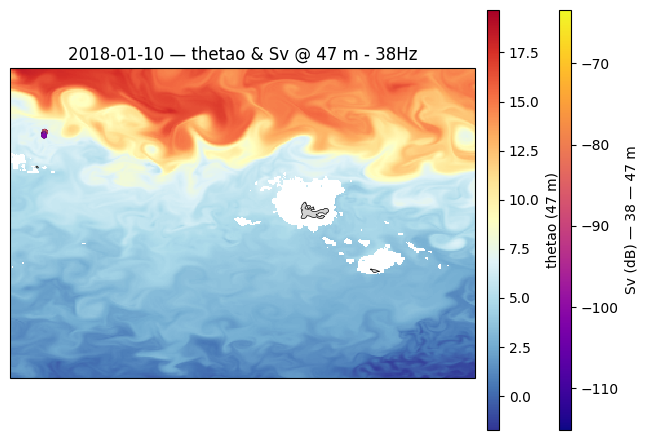

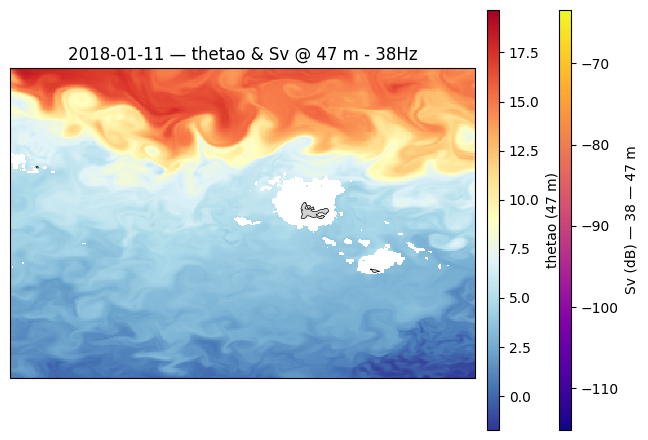

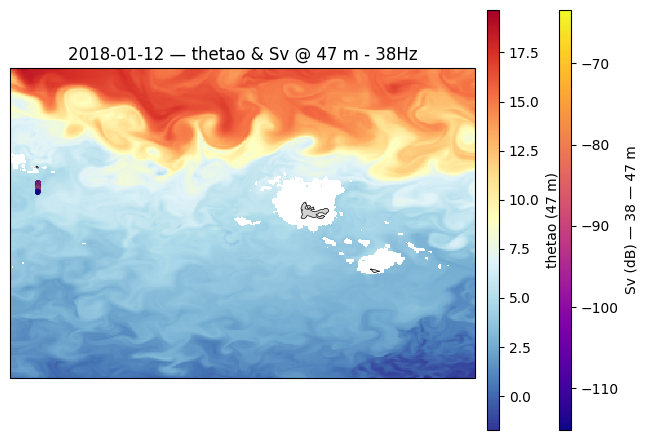

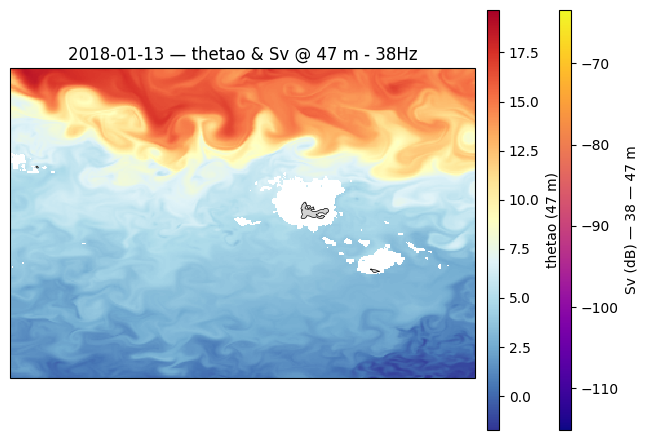

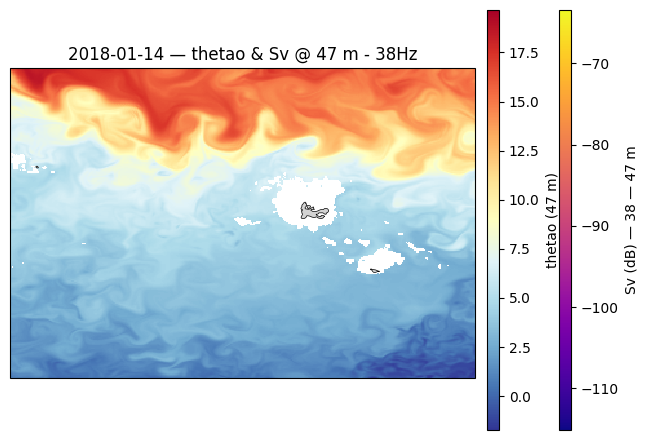

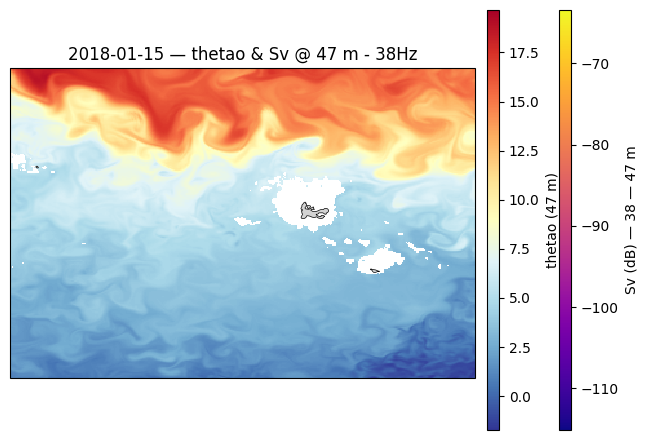

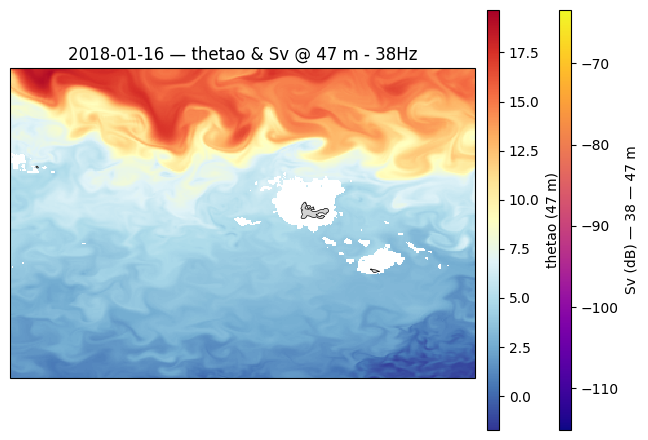

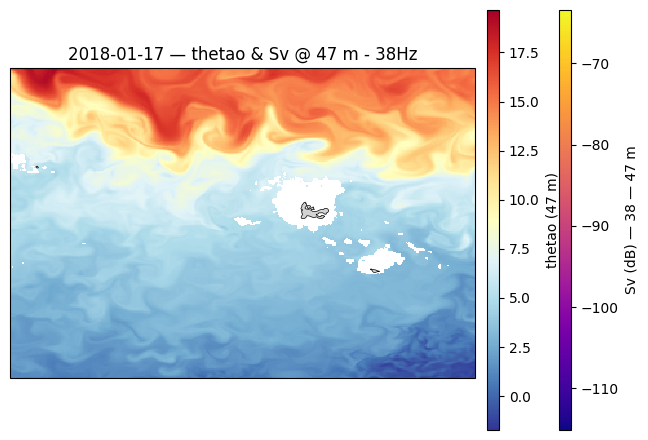

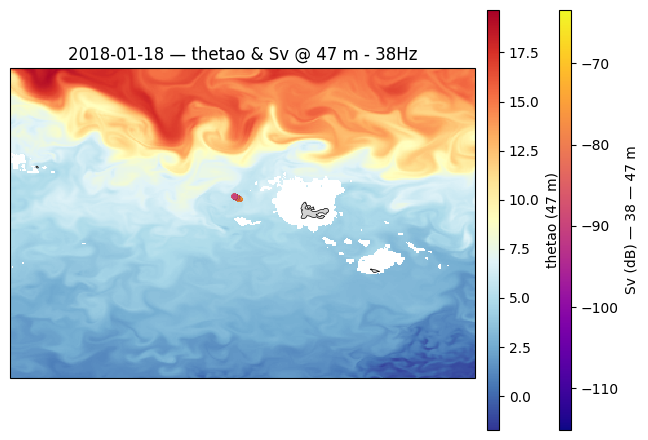

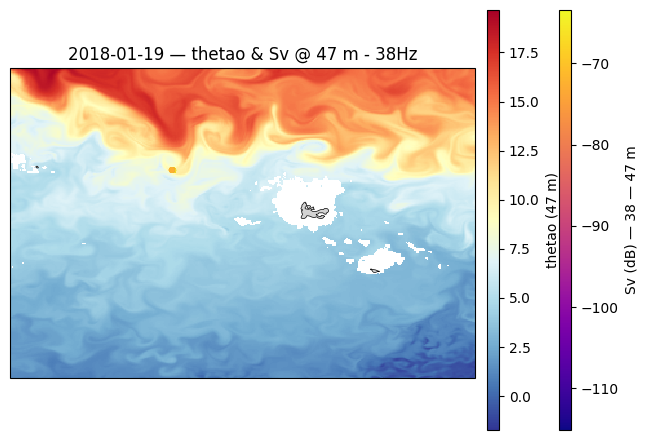

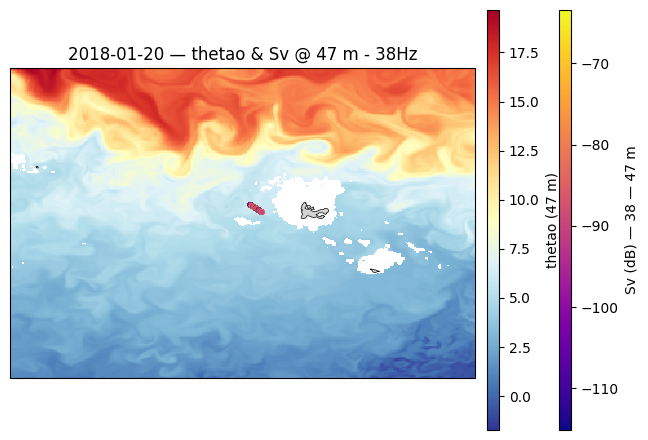

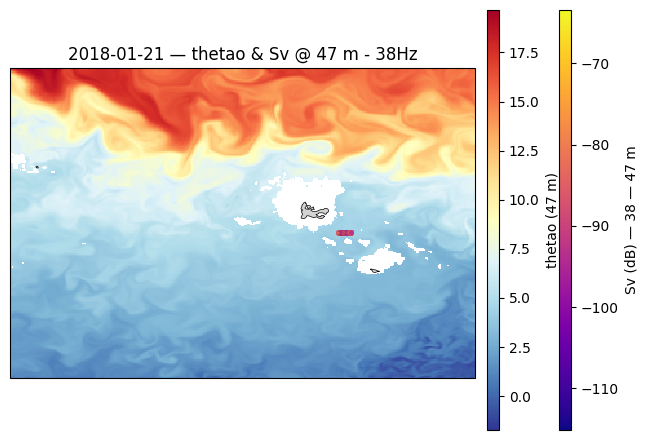

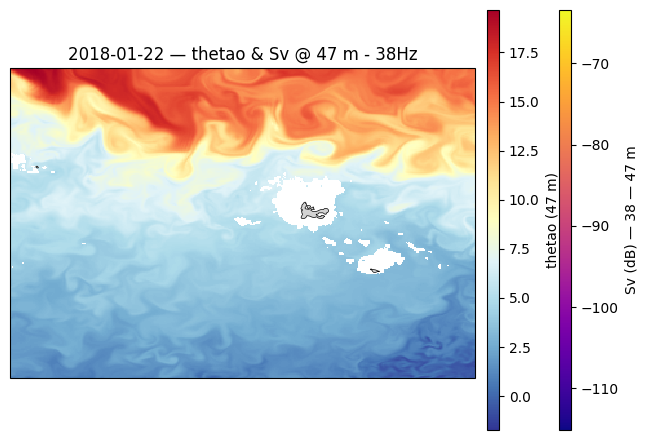

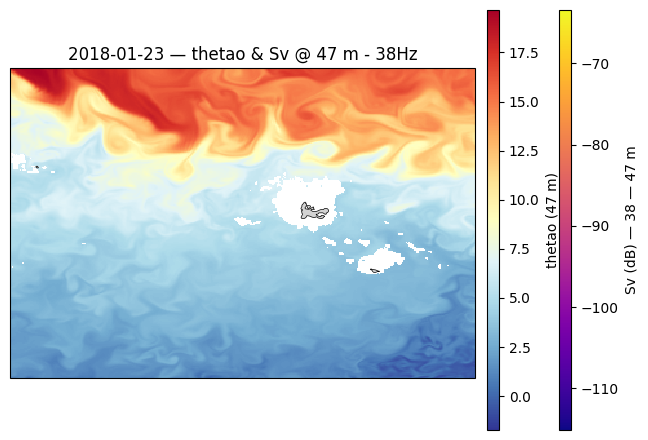

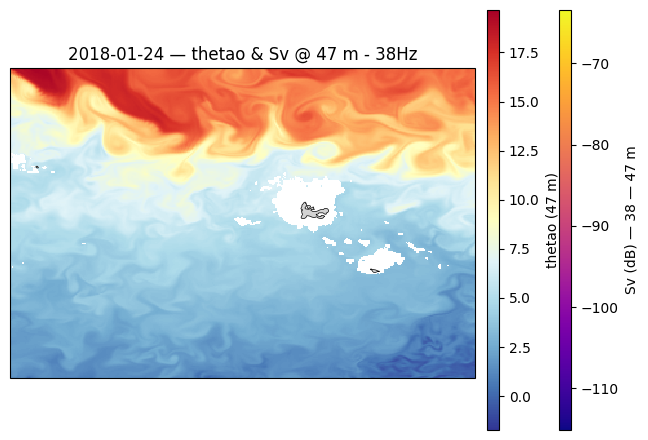

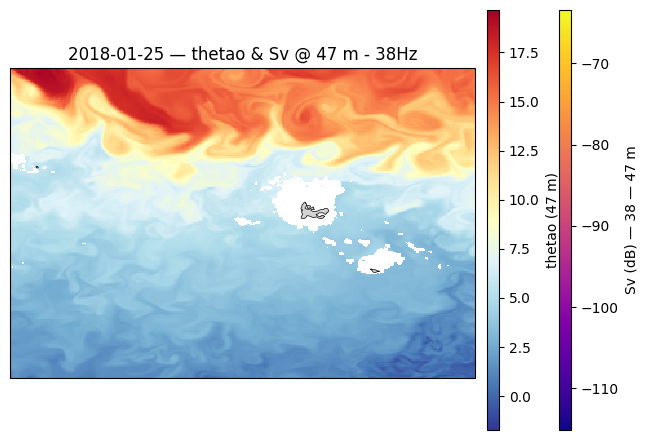

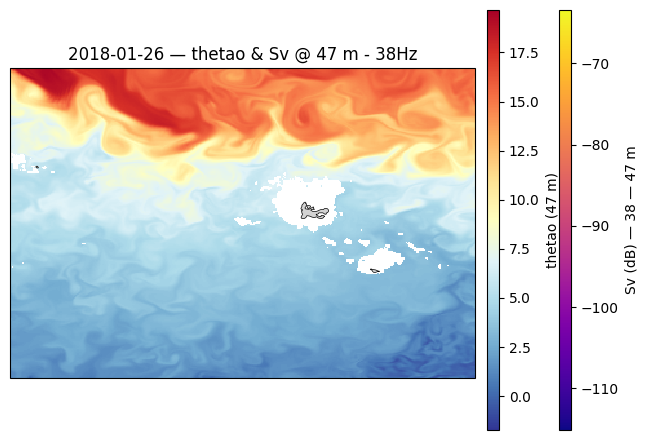

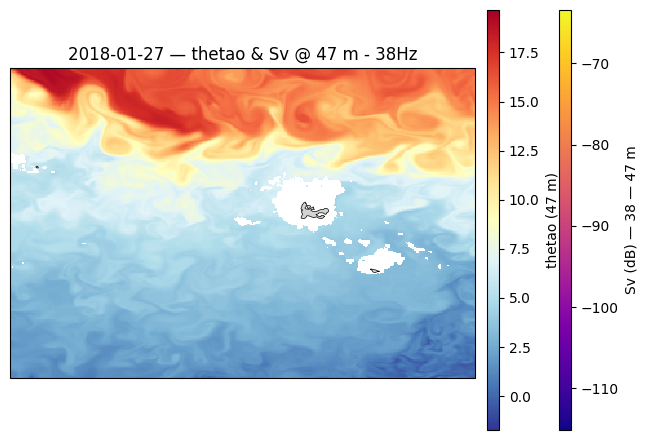

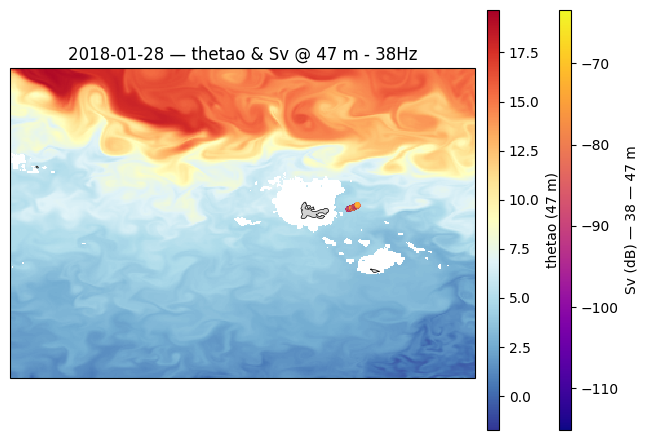

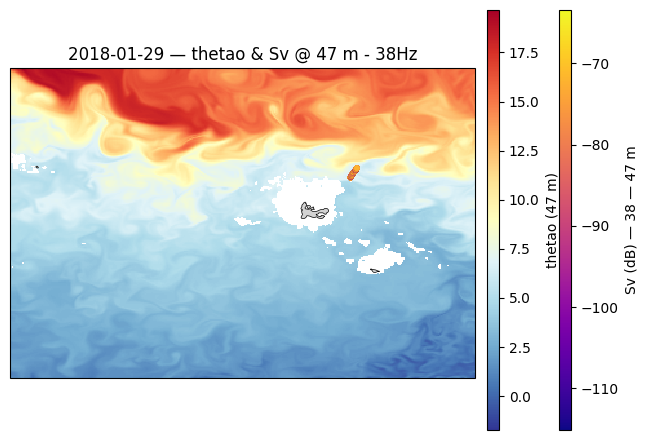

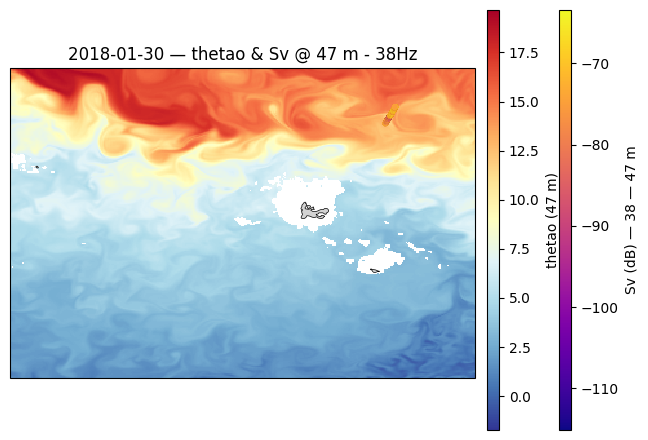

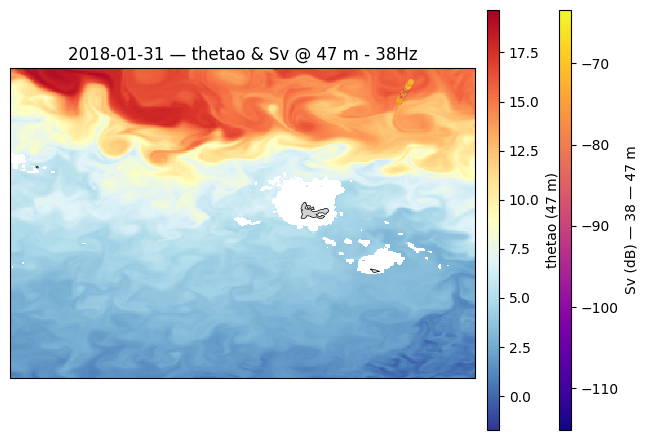

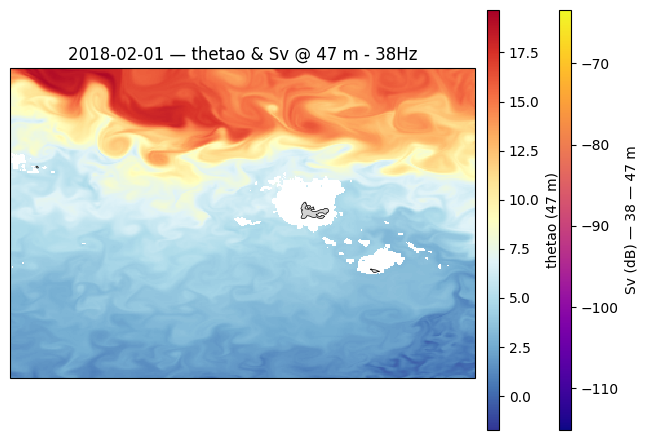

In [45]:
plot_transect_data_env(38, 1, "thetao", path_env=path_temp_sal, target_depth=50)